# Architectures de réseaux neuronaux

CSI 4506 - automne 2026

Marcel Turcotte  
Version: août 9, 2026 12h46

# Préambule

## Message du jour

<https://www.youtube.com/watch?v=78xby7PtGC8>

[Will transformers drive AI in 10
years?](https://www.youtube.com/watch?v=78xby7PtGC8), Andrej Karpathy,
2025-10-27.

[Andrej Karpathy](https://karpathy.ai) est un informaticien
slovaquo-canadien né en 1986 à Bratislava, qui a déménagé à Toronto avec
sa famille à l’âge de 15 ans. Il a obtenu un baccalauréat en
informatique et en physique à l’Université de Toronto (2009) ainsi
qu’une maîtrise à l’Université de la Colombie-Britannique (2011), où il
a travaillé avec son directeur Michiel van de Panne sur l’apprentissage
de contrôleurs pour des figures simulées physiquement. Il a ensuite
complété un doctorat à l’Université Stanford sous la supervision de
[Fei-Fei Li](https://profiles.stanford.edu/fei-fei-li), portant sur
l’intersection entre la vision par ordinateur et le traitement du
langage naturel.

- Membre fondateur et chercheur chez **OpenAI** (2015 – 2017).
- Directeur principal de l’IA et de la vision Autopilot chez **Tesla,
  Inc.** (2017 – 2022).
- Retour chez **OpenAI** en 2023 pour diriger une petite équipe
  travaillant sur l’amélioration des modèles (notamment **GPT-4**),
  avant de quitter l’entreprise en 2024.
- Fondateur de **Eureka Labs** (depuis 2024), une jeune entreprise axée
  sur l’IA et l’éducation.

## Objectifs d’apprentissage

- **Expliquer** la hiérarchie des concepts dans l’apprentissage profond
- **Comparer** les réseaux neuronaux profonds et peu profonds
- **Décrire** la structure et la fonction des réseaux neuronaux
  convolutifs (CNNs)
- **Comprendre** les opérations de convolution utilisant des noyaux
- **Expliquer** les champs récepteurs, le padding et le stride dans les
  CNNs
- **Discuter** du rôle et des avantages de la couche de pooling

Dans le cours précédent, nous avons examiné l’algorithme de
rétropropagation, qui offre une méthode systématique pour calculer les
dérivées partielles de la fonction de perte. Ce calcul est essentiel
pour appliquer l’algorithme de descente de gradient, permettant ainsi
l’ajustement des poids dans un réseau de neurones profond. Aujourd’hui,
nous aborderons un programme intensif. Nous portons notre attention sur
les réseaux de neurones convolutifs.

L’étude des réseaux convolutifs présente plusieurs niveaux de
complexité. N’hésitez pas à poser des questions si vous avez besoin de
clarifications.

Objectifs d’apprentissage détaillés.

1.  **Expliquer la hiérarchie des concepts dans l’apprentissage
    profond**
    - Comprendre comment les modèles d’apprentissage profond
      construisent des représentations hiérarchiques des données.
    - Reconnaître comment cette hiérarchie réduit le besoin d’ingénierie
      manuelle des attributs.
2.  **Comparer les réseaux neuronaux profonds et peu profonds**
    - Discuter des raisons pour lesquelles les réseaux profonds sont
      plus efficaces en termes de paramètres que les réseaux peu
      profonds.
    - Expliquer les avantages de la profondeur dans les architectures de
      réseaux neuronaux.
3.  **Décrire la structure et la fonction des réseaux neuronaux
    convolutifs (CNNs)**
    - Comprendre comment les CNNs détectent des motifs locaux dans les
      données.
    - Expliquer comment les couches convolutionnelles réduisent le
      nombre de paramètres grâce au partage des poids.
4.  **Comprendre les opérations de convolution utilisant des noyaux**
    - Décrire comment les noyaux (filtres) sont appliqués sur les
      données d’entrée pour réaliser des convolutions.
    - Expliquer comment les cartes de attributs sont générées à partir
      des opérations de convolution.
5.  **Expliquer les champs récepteurs, le padding, et le stride dans les
    CNNs**
    - Définir le concept de champ récepteur dans les couches
      convolutionnelles.
    - Comprendre comment le padding et le stride affectent les
      dimensions de sortie et le calcul.
6.  **Discuter du rôle et des avantages des couches de pooling**
    - Expliquer comment les couches de pooling réduisent les dimensions
      spatiales et contrôlent l’overfitting.
    - Décrire comment le pooling introduit une invariance de translation
      dans les CNNs.

## Que voyez-vous ?

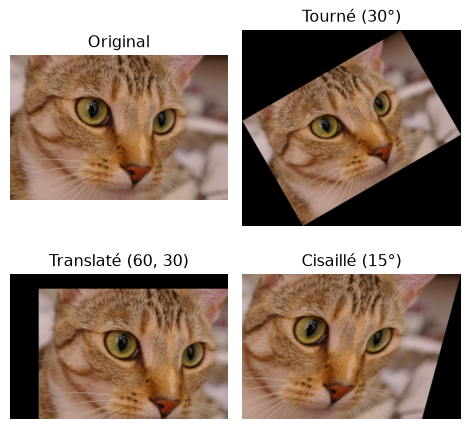

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from skimage.util import img_as_float

# Charger une image échantillon (Chelsea le chat)
image = img_as_float(data.chelsea())

# Définir les transformations
def translate(image, tx=50, ty=30):
    tform = transform.AffineTransform(translation=(tx, ty))
    return transform.warp(image, tform.inverse)

def rotate(image, angle=30):
    return transform.rotate(image, angle, resize=True)

def shear(image, shear_deg=15):
    shear_rad = np.deg2rad(shear_deg)
    tform = transform.AffineTransform(shear=shear_rad)
    return transform.warp(image, tform.inverse)

# Appliquer les transformations
rotated = rotate(image, 30)
translated = translate(image, 60, 30)
sheared = shear(image, 15)

# Créer une grille 2x2
fig, axes = plt.subplots(2, 2, figsize=(5, 5))
axes = axes.ravel()
titles = ['Original', 'Tourné (30°)', 'Translaté (60, 30)', 'Cisaillé (15°)']
images = [image, rotated, translated, sheared]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

Même si ces images semblent très différentes dans l’espace des pixels,
vous pouvez toujours reconnaître le chat. Un réseau neuronal
convolutionnel apprend des filtres qui sont robustes à ces
transformations — c’est pourquoi il est si puissant pour les tâches de
vision.

# Convolution

## Hiérarchie des concepts

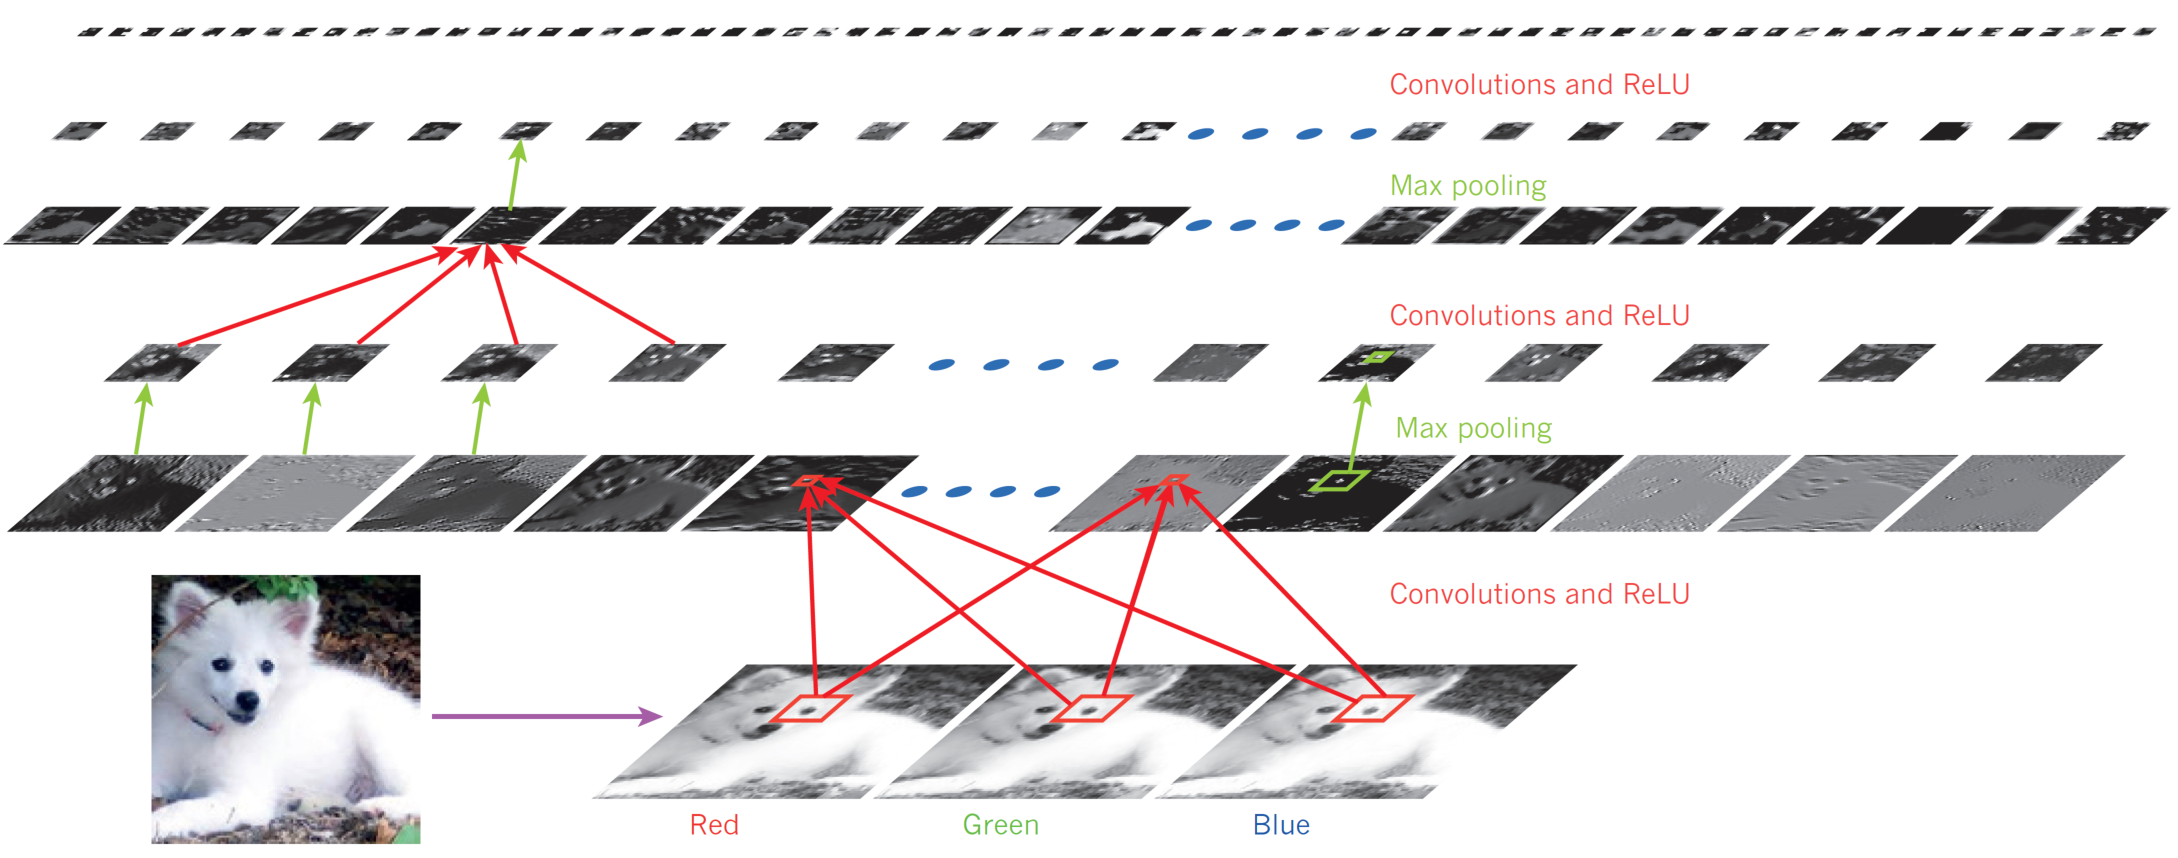

**Attribution**: LeCun et al. (2015)

Dans le livre “Deep Learning” (Goodfellow et al. 2016), les auteurs
Goodfellow, Bengio, et Courville définissent l’apprentissage profond
comme un sous-ensemble de l’apprentissage automatique permettant aux
ordinateurs de “comprendre le monde en termes d’une hiérarchie de
concepts”.

Cette approche hiérarchique est l’une des contributions les plus
significatives de l’apprentissage profond. Elle réduit le besoin
d’ingénierie manuelle des attributs et recentre l’attention sur
l’ingénierie des architectures de réseaux neuronaux.

Les réseaux de neurones convolutifs (CNN) ont eu un impact profond sur
le domaine de l’apprentissage automatique, en particulier dans les
domaines du traitement d’images et de vidéos.

1.  **Révolution de la reconnaissance d’images** : Les CNN ont
    considérablement fait progresser l’état de l’art en matière de
    reconnaissance et de classification d’images, atteignant une haute
    précision sur divers ensembles de données. Cela a conduit à des
    percées dans des domaines tels que l’imagerie médicale, les
    véhicules autonomes et la reconnaissance faciale.

2.  **Extraction de caractéristiques** : Les CNN apprennent
    automatiquement à extraire des caractéristiques à partir de données
    brutes, éliminant ainsi le besoin d’ingénierie manuelle des
    caractéristiques. Cette capacité a été cruciale pour traiter des
    motifs de données complexes et a élargi l’applicabilité de
    l’apprentissage automatique à divers domaines.

3.  **Apprentissage par transfert** : Les CNN facilitent l’apprentissage
    par transfert, où des réseaux pré-entraînés sur de grands ensembles
    de données peuvent être ajustés pour des tâches spécifiques avec des
    données limitées. Cela a rendu les CNN accessibles et efficaces pour
    un large éventail d’applications au-delà de leur champ de formation
    initial.

4.  **Avancées en apprentissage profond** : Le succès des CNN a stimulé
    la recherche dans les architectures d’apprentissage profond,
    inspirant le développement de modèles plus sophistiqués tels que les
    réseaux de neurones récurrents (RNN), les réseaux de mémoire à long
    terme (LSTM) et les modèles de transformateurs.

5.  **Domaines d’application étendus** : Au-delà du traitement d’images,
    les CNN ont été adaptés au traitement du langage naturel, au
    traitement audio, et même en bio-informatique pour des tâches telles
    que la prédiction de structures protéiques et la génomique.

6.  **Implications pour les applications du monde réel** : Les CNN ont
    permis des applications pratiques dans des domaines tels que la
    santé, où ils aident à l’imagerie diagnostique, et la sécurité, où
    ils améliorent les systèmes de surveillance. Ils ont également
    contribué aux avancées en réalité virtuelle, dans le jeu vidéo et en
    réalité augmentée.

Nous avons exploré les algorithmes des k plus proches voisins ainsi que
les arbres de décision afin de vous offrir une perspective élargie sur
l’apprentissage automatique, qui ne se limite pas uniquement aux réseaux
de neurones. Actuellement, nous étudions les réseaux de neurones
convolutifs pour illustrer la diversité des architectures existantes
dans ce domaine. Bien qu’il soit impossible de couvrir tous les aspects
en détail, notre objectif est de vous fournir une compréhension solide
des différents paradigmes de l’apprentissage automatique.

## Hiérarchie des concepts

- Chaque couche détecte des **motifs** à partir de la sortie de la
  **couche précédente**.
  - En d’autres termes, en progressant de l’entrée à la sortie du
    réseau, le réseau découvre des “**motifs de motifs**”.
    - En analysant une image, les réseaux détectent d’abord des motifs
      simples, tels que des **lignes verticales**, **horizontales**,
      **diagonales**, des **arcs**, etc.
    - Ceux-ci sont ensuite combinés pour former des **coins**, des
      **croix**, etc.
- (Cela explique comment fonctionne l’**apprentissage par transfert** et
  pourquoi il est pertinent de ne sélectionner que les couches
  inférieures.)

## Mais aussi…

> “Un MLP avec une seule **couche cachée** peut théoriquement modéliser
> même les fonctions les plus **complexes**, à condition qu’il dispose
> d’**assez de neurones**. Mais pour des problèmes complexes, les
> **réseaux profonds** ont une **efficacité paramétrique** bien plus
> élevée que les réseaux peu profonds : ils peuvent modéliser des
> fonctions complexes en utilisant **exponentiellement moins de
> neurones** que les réseaux peu profonds, leur permettant d’atteindre
> de bien **meilleures performances** avec la même quantité de données
> d’entraînement.”

Géron (2019) § 10

## Combien de couches ?

- Commencez avec une seule couche, puis **augmentez le nombre de
  couches** jusqu’à ce que le modèle commence à **sur-apprendre** les
  données d’entraînement.
- **Ajustez finement** le modèle en ajoutant des techniques de
  régularisation (couches de dropout, termes de régularisation, etc.).

Le nombre de neurones et autres hyperparamètres sont déterminés à l’aide
d’une recherche par grille.

## Observation

Prenons un réseau de neurones **feed-forward** (FFN) et son modèle :

$$
  h_{W,b}(X) = \phi_k(\ldots \phi_2(\phi_1(X)) \ldots)
$$

où

$$
  \phi_l(Z) = \sigma(W_l Z + b_l)
$$

pour $l=1 \ldots k$. - Le **nombre de paramètres** augmente rapidement :

$$
  (\text{taille de la couche}_{l-1} + 1) \times \text{taille de la couche}_{l}
$$

**Deux couches** de **1 000 unités** impliquent **1 000 000** paramètres
!

## Tâche de classification d’Images

- Considérons une **image RGB** de dimensions $224 \times 224$, ce qui
  est relativement petit selon les critères contemporains.

- L’image est composée de $224 \times 224 \times 3 = 150,528$
  **attributs d’entrée**.

- Un réseau de neurones avec seulement une **couche dense cachée
  unique** nécessiterait plus de 22,658,678,784 (**22 milliards**) de
  paramètres, soulignant la complexité computationnelle impliquée.

## Réseau neuronal convolutif (CNN)

<https://www.youtube.com/watch?v=QzY57FaENXg>

Un excellent aperçu des CNNs à haut niveau.

## Réseau neuronal convolutif (CNN)

- Les informations cruciales sur les motifs sont souvent **locales**.

  - Par exemple, les arêtes, coins, croix.

- Les **couches convolutionnelles** réduisent significativement les
  paramètres.

  - Contrairement aux couches denses, les neurones dans une couche
    convolutionnelle ne sont **pas complètement connectés** à la couche
    précédente.

  - Les neurones ne se connectent qu’à leurs **champs récepteurs**
    (zones rectangulaires).

Les **réseaux convolutionnels** proviennent du domaine de la **vision
par ordinateur**, ce qui explique leur compatibilité intrinsèque avec
les **entrées structurées en grille**.

La publication originale de Yann Lecun a été citée près de 35 000
fois (Lecun et al. 1998)

# Noyau

## Noyau

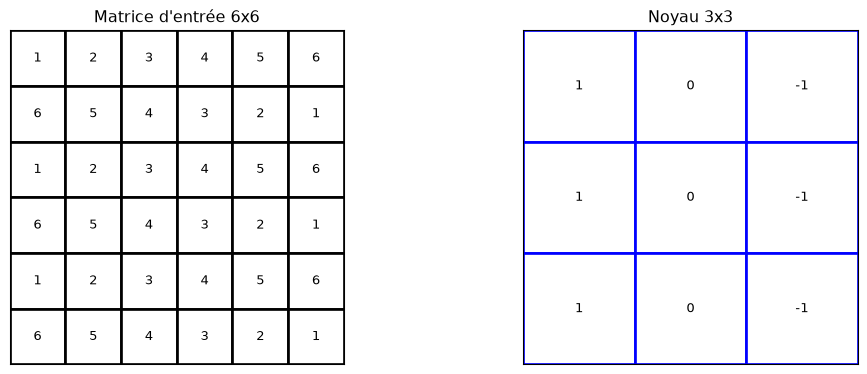

Un **noyau** (*kernel*) est une petite matrice, généralement de taille
$3 \times 3$, $5 \times 5$, ou similaire, qui glisse sur les données
d’entrée (comme une image) pour effectuer la convolution.

Le processus computationnel détaillé sera élaboré par la suite. À ce
stade, il suffit de noter que le noyau est systématiquement parcouru à
travers la matrice d’entrée, générant une sortie distincte à chaque
itération.

## Noyau

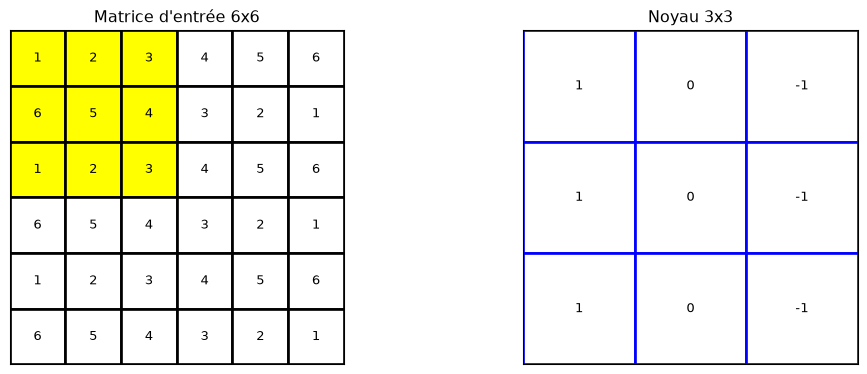

Au départ, le noyau est positionné pour chevaucher le coin supérieur
gauche de la matrice d’entrée.

## Noyau

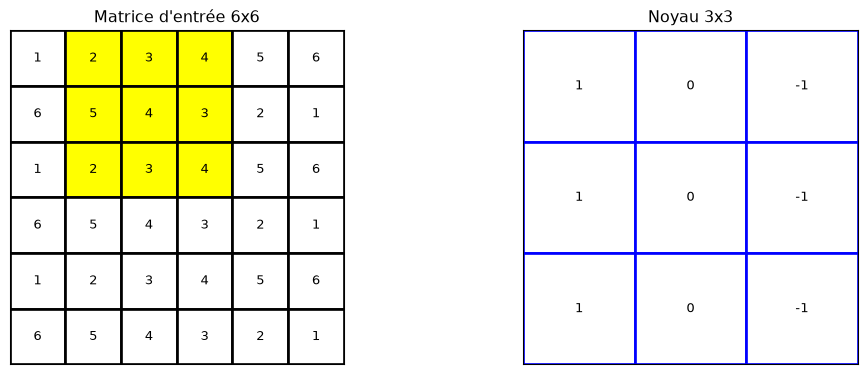

Il peut être déplacé vers la droite trois fois.

## Noyau

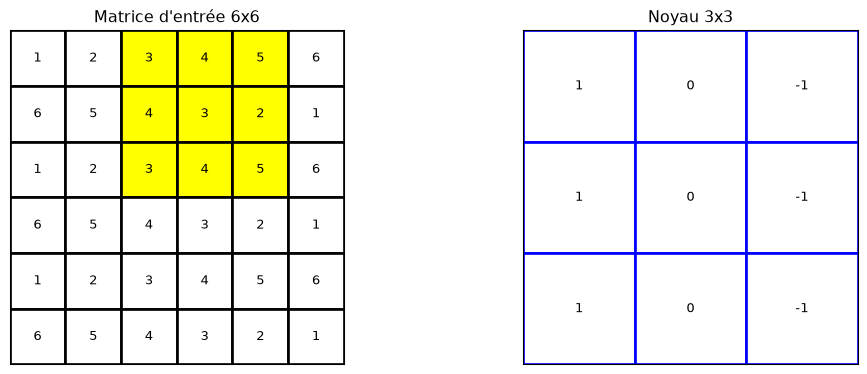

## Noyau

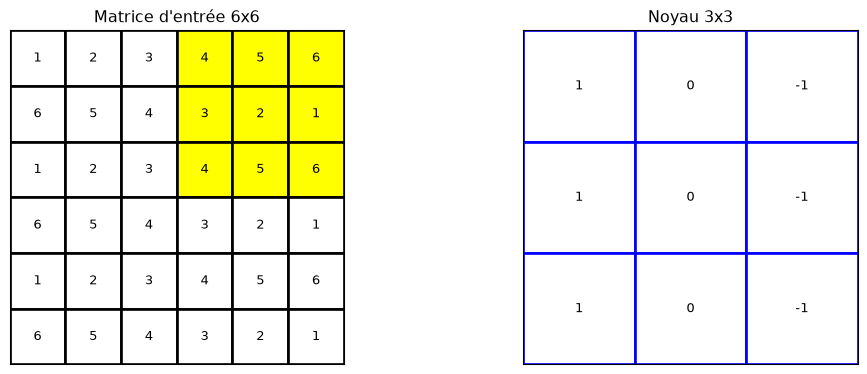

## Noyau

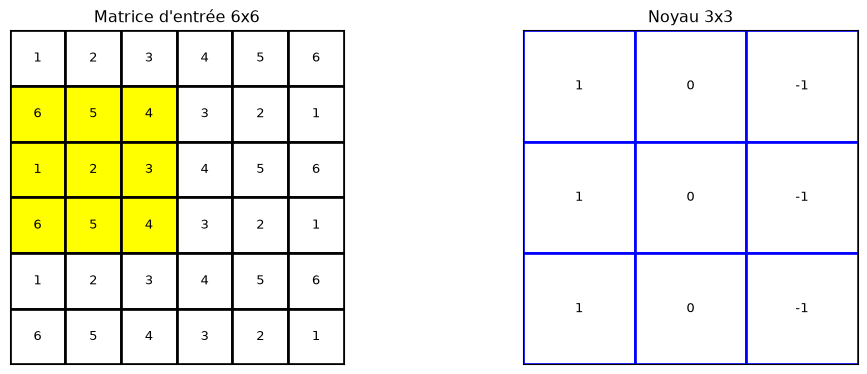

Il se déplace ensuite sur la deuxième rangée. On peut alors le déplacer
à nouveau trois fois.

## Déplacer le noyau

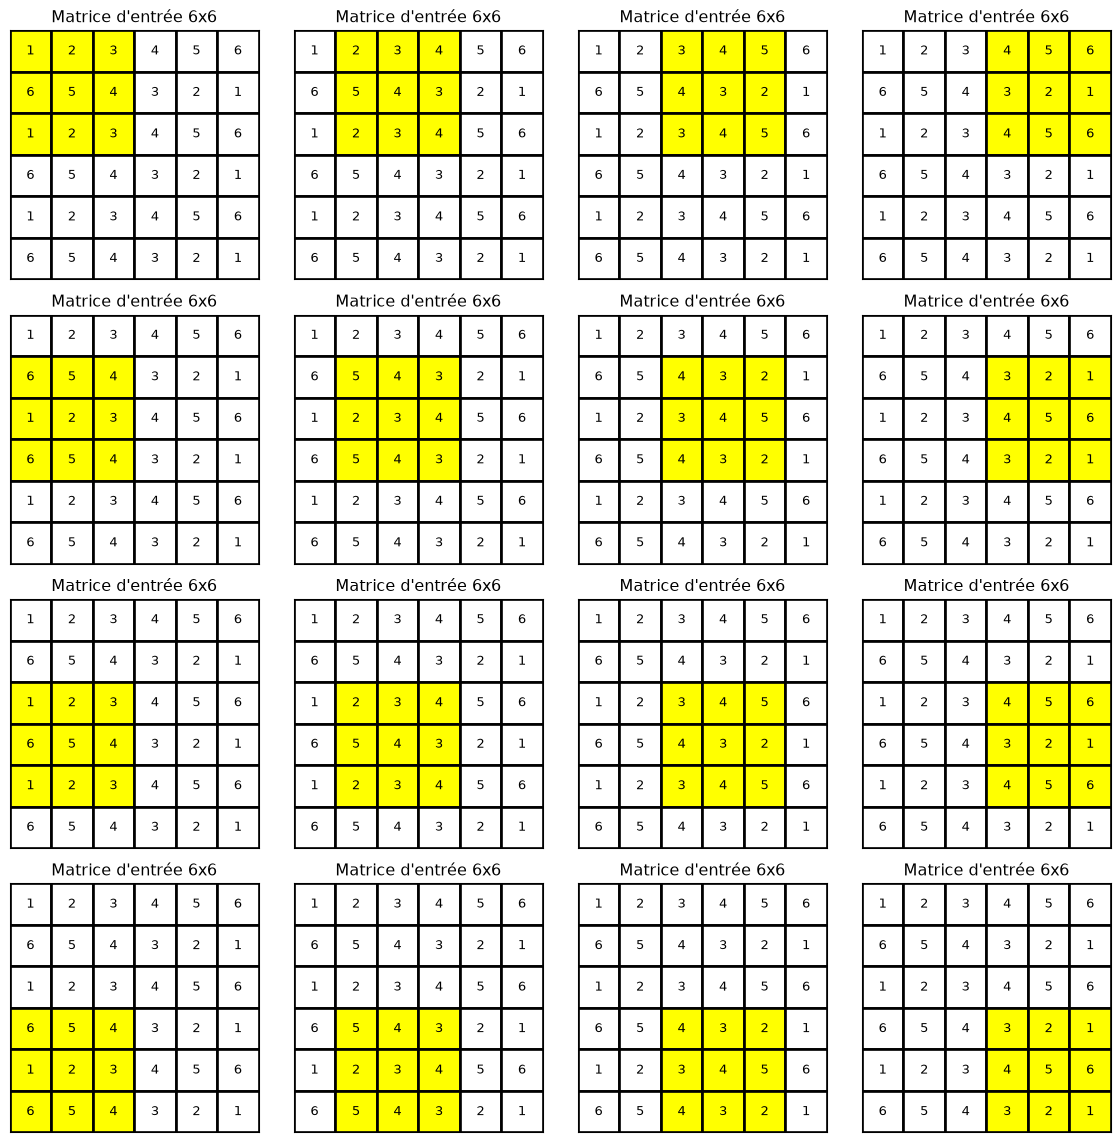

## Noyau

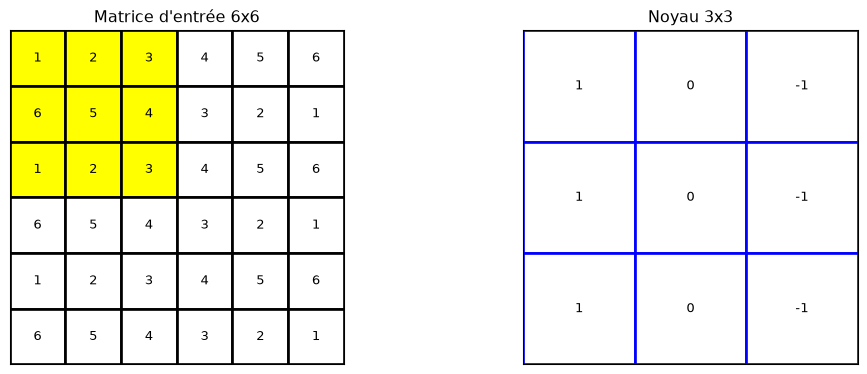

Avec le noyau placé sur une région spécifique de la matrice d’entrée, la
**convolution** consiste en une **multiplication élément par élément**
(chaque élément du noyau est multiplié par l’élément correspondant de la
région de la matrice d’entrée qu’il chevauche), suivie d’une
**sommation** des résultats pour produire une **valeur scalaire
unique**.

## Noyau

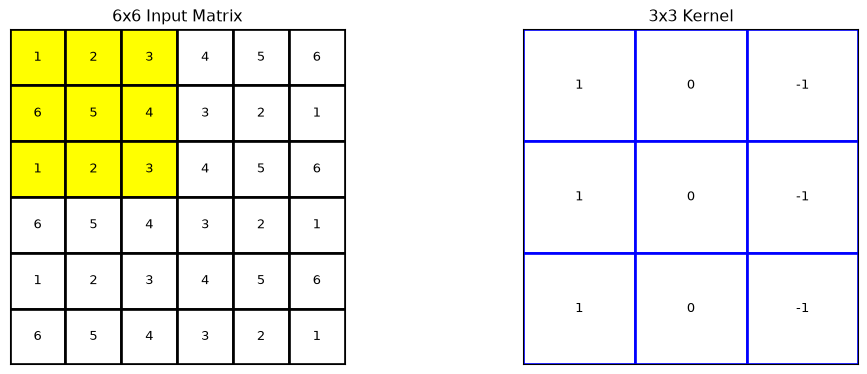

$1 \times 1 + 2 \times 0 + 3 \times (-1) + 6 \times 1 + 5 \times 0 + 4 \times (-1) + 1 \times 1 + 2 \times 0 + 3 \times (-1) = -2$

## Noyau

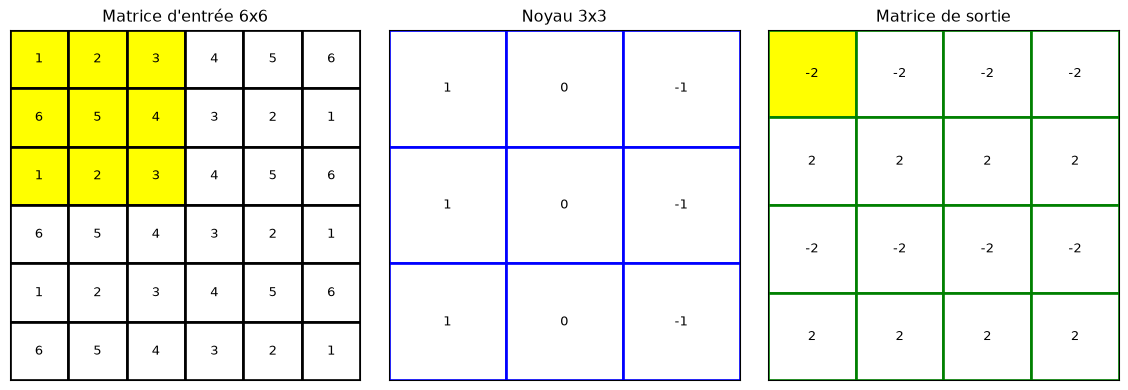

Les 16 valeurs résultantes peuvent être organisées dans une **matrice de
sortie**. L’élément à la position (0,0) de cette matrice de sortie
représente le résultat de l’application de l’opération de convolution
avec le noyau à la position initiale sur la matrice d’entrée. Dans les
réseaux neuronaux convolutifs, la matrice de sortie est appelée **carte
de attributs** (*feature map*).

On parle de carte d’attributs parce que ces sorties servent d’attributs
pour la couche suivante. Dans les CNN, le terme “carte d’attributs’”
désigne la sortie d’une couche de convolution après l’application de
filtres aux données d’entrée. Ces cartes d’attributs capturent divers
motifs ou attributs de l’entrée, tels que les contours ou les textures
dans les données d’image.

Les cartes des attributs produites par une couche deviennent l’entrée de
la couche suivante, servant ainsi d’attributs que cette dernière peut
utiliser pour apprendre des motifs plus complexes. Ce processus
hiérarchique d’extraction d’attributs est une caractéristique clé des
CNN, leur permettant de construire progressivement des représentations
plus abstraites et de haut niveau des données d’entrée à mesure que la
profondeur du réseau augmente.

## Floutage

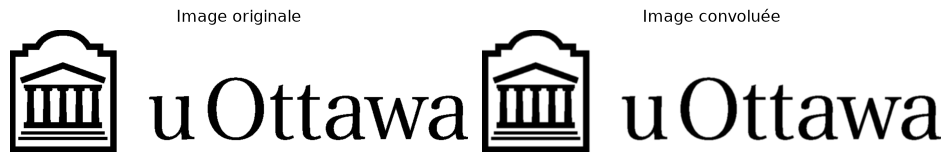

In [14]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

def apply_kernel_to_image(image_path, kernel):
    # Charger l'image et la convertir en niveaux de gris
    image = Image.open(image_path).convert('L')
    image_array = np.array(image)

    # Appliquer la convolution en utilisant le noyau fourni
    convolved_array = convolve(image_array, kernel, mode='reflect')

    # Convertir le tableau convolué en image
    convolved_image = Image.fromarray(convolved_array)

    # Afficher l'image originale et convoluée
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.title('Image originale')
    plt.imshow(image_array, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Image convoluée')
    plt.imshow(convolved_image, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Définir le noyau de moyenne 3x3
kernel = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

# Appliquer le noyau à l'image (spécifiez le chemin de l'image)
image_path = '../../assets/images/uottawa_hor_black.png'
apply_kernel_to_image(image_path, kernel)

In [15]:
# Define the 3x3 averaging kernel

kernel = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

Un pixel est transformé en **la moyenne de lui-même et de ses huit
voisins** environnants, ce qui crée un effet de flou (*blurring*) sur
l’image.

L’application de noyaux aux images est une pratique de longue date dans
le domaine du traitement d’images.

## Détection des bords verticaux

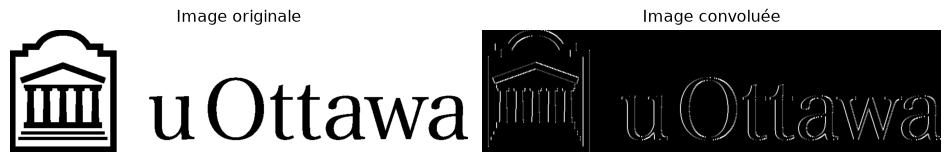

In [17]:
# Définir le noyau de détection des bords verticaux 3x3

kernel = np.array([
    [-0.25, 0, 0.25],
    [-0.25, 0, 0.25],
    [-0.25, 0, 0.25]
])

Ce noyau détecte les bords verticaux en **accentuant les différences
d’intensité entre les colonnes adjacentes**. Il soustrait les valeurs
des pixels de gauche de celles de droite, améliorant ainsi les
transitions verticales tout en supprimant les régions uniformes.

Il s’agit d’un type de **noyau de détection de contours**,
spécifiquement un filtre de gradient horizontal ou un opérateur de
Sobel. Il est conçu pour détecter les changements d’intensité le long de
l’axe horizontal, en mettant en évidence les contours verticaux dans une
image.

Lorsque ce noyau est convolué avec une image :

- Il met en évidence les contours verticaux en calculant la différence
  d’intensité des pixels entre les côtés gauche et droit d’un point.
- Les valeurs négatives (-1) à gauche soustraient de l’intensité, tandis
  que les valeurs positives (1) à droite ajoutent de l’intensité,
  mesurant ainsi effectivement le gradient horizontal.
- Les zéros au milieu ignorent la contribution du pixel central, se
  concentrant uniquement sur le contraste entre les voisins gauche et
  droit.

Le résultat est une image où :

- Les contours verticaux (par exemple, la frontière entre un objet
  sombre et un fond clair) apparaissent lumineux ou sombres, selon la
  direction du changement d’intensité.
- Les contours horizontaux ou les zones uniformes ont tendance à être
  supprimés (proches de zéro).

Imaginez glisser ce noyau sur une image comme un scanner. Pour chaque
pixel :

- Il regarde les pixels à sa gauche (en soustrayant leur valeur avec -1)
  et à sa droite (en ajoutant leur valeur avec 1).

- Si les côtés gauche et droit sont similaires (par exemple, même
  couleur), le résultat est proche de zéro (pas de contour).

- Si la gauche est sombre et la droite est claire (ou vice versa), le
  résultat est une valeur positive ou négative forte, montrant un
  contour vertical.

Cela est utile en vision par ordinateur (comme dans les CNNs de Tesla)
pour aider à détecter les contours d’objets ou les lignes de voie en
mettant en évidence où les valeurs des pixels changent fortement dans la
direction horizontale.

## Détection des bords horizontaux

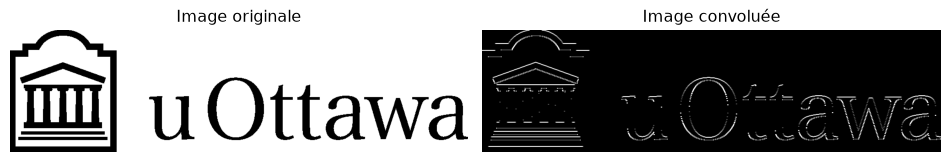

In [19]:
# Définir le noyau de détection des bords horizontaux 3x3

kernel = np.array([
    [-0.25, -0.25, -0.25],
    [0, 0, 0],
    [0.25, 0.25, 0.25]
])

Ce noyau détecte les bords horizontaux en **mettant en évidence les
différences d’intensité entre les lignes adjacentes**. Il soustrait les
valeurs des pixels de la ligne supérieure de celles de la ligne
inférieure, accentuant les transitions horizontales tout en minimisant
les zones uniformes.

## Traitement d’images

<https://www.youtube.com/watch?v=8rrHTtUzyZA>

Utilise le langage de programmation **[Julia](https://julialang.org)**.

## Mais qu’est-ce qu’une convolution ?

<https://youtu.be/KuXjwB4LzSA>

**Convolution** au-delà de son application dans le traitement d’images.

## Noyaux

Contrairement au traitement d’images, où les noyaux sont définis
manuellement par l’utilisateur, dans le cas des réseaux convolutifs, les
noyaux sont automatiquement appris par le réseau.

À suivre $\ldots$

# Champ récepteur

## Champ récepteur

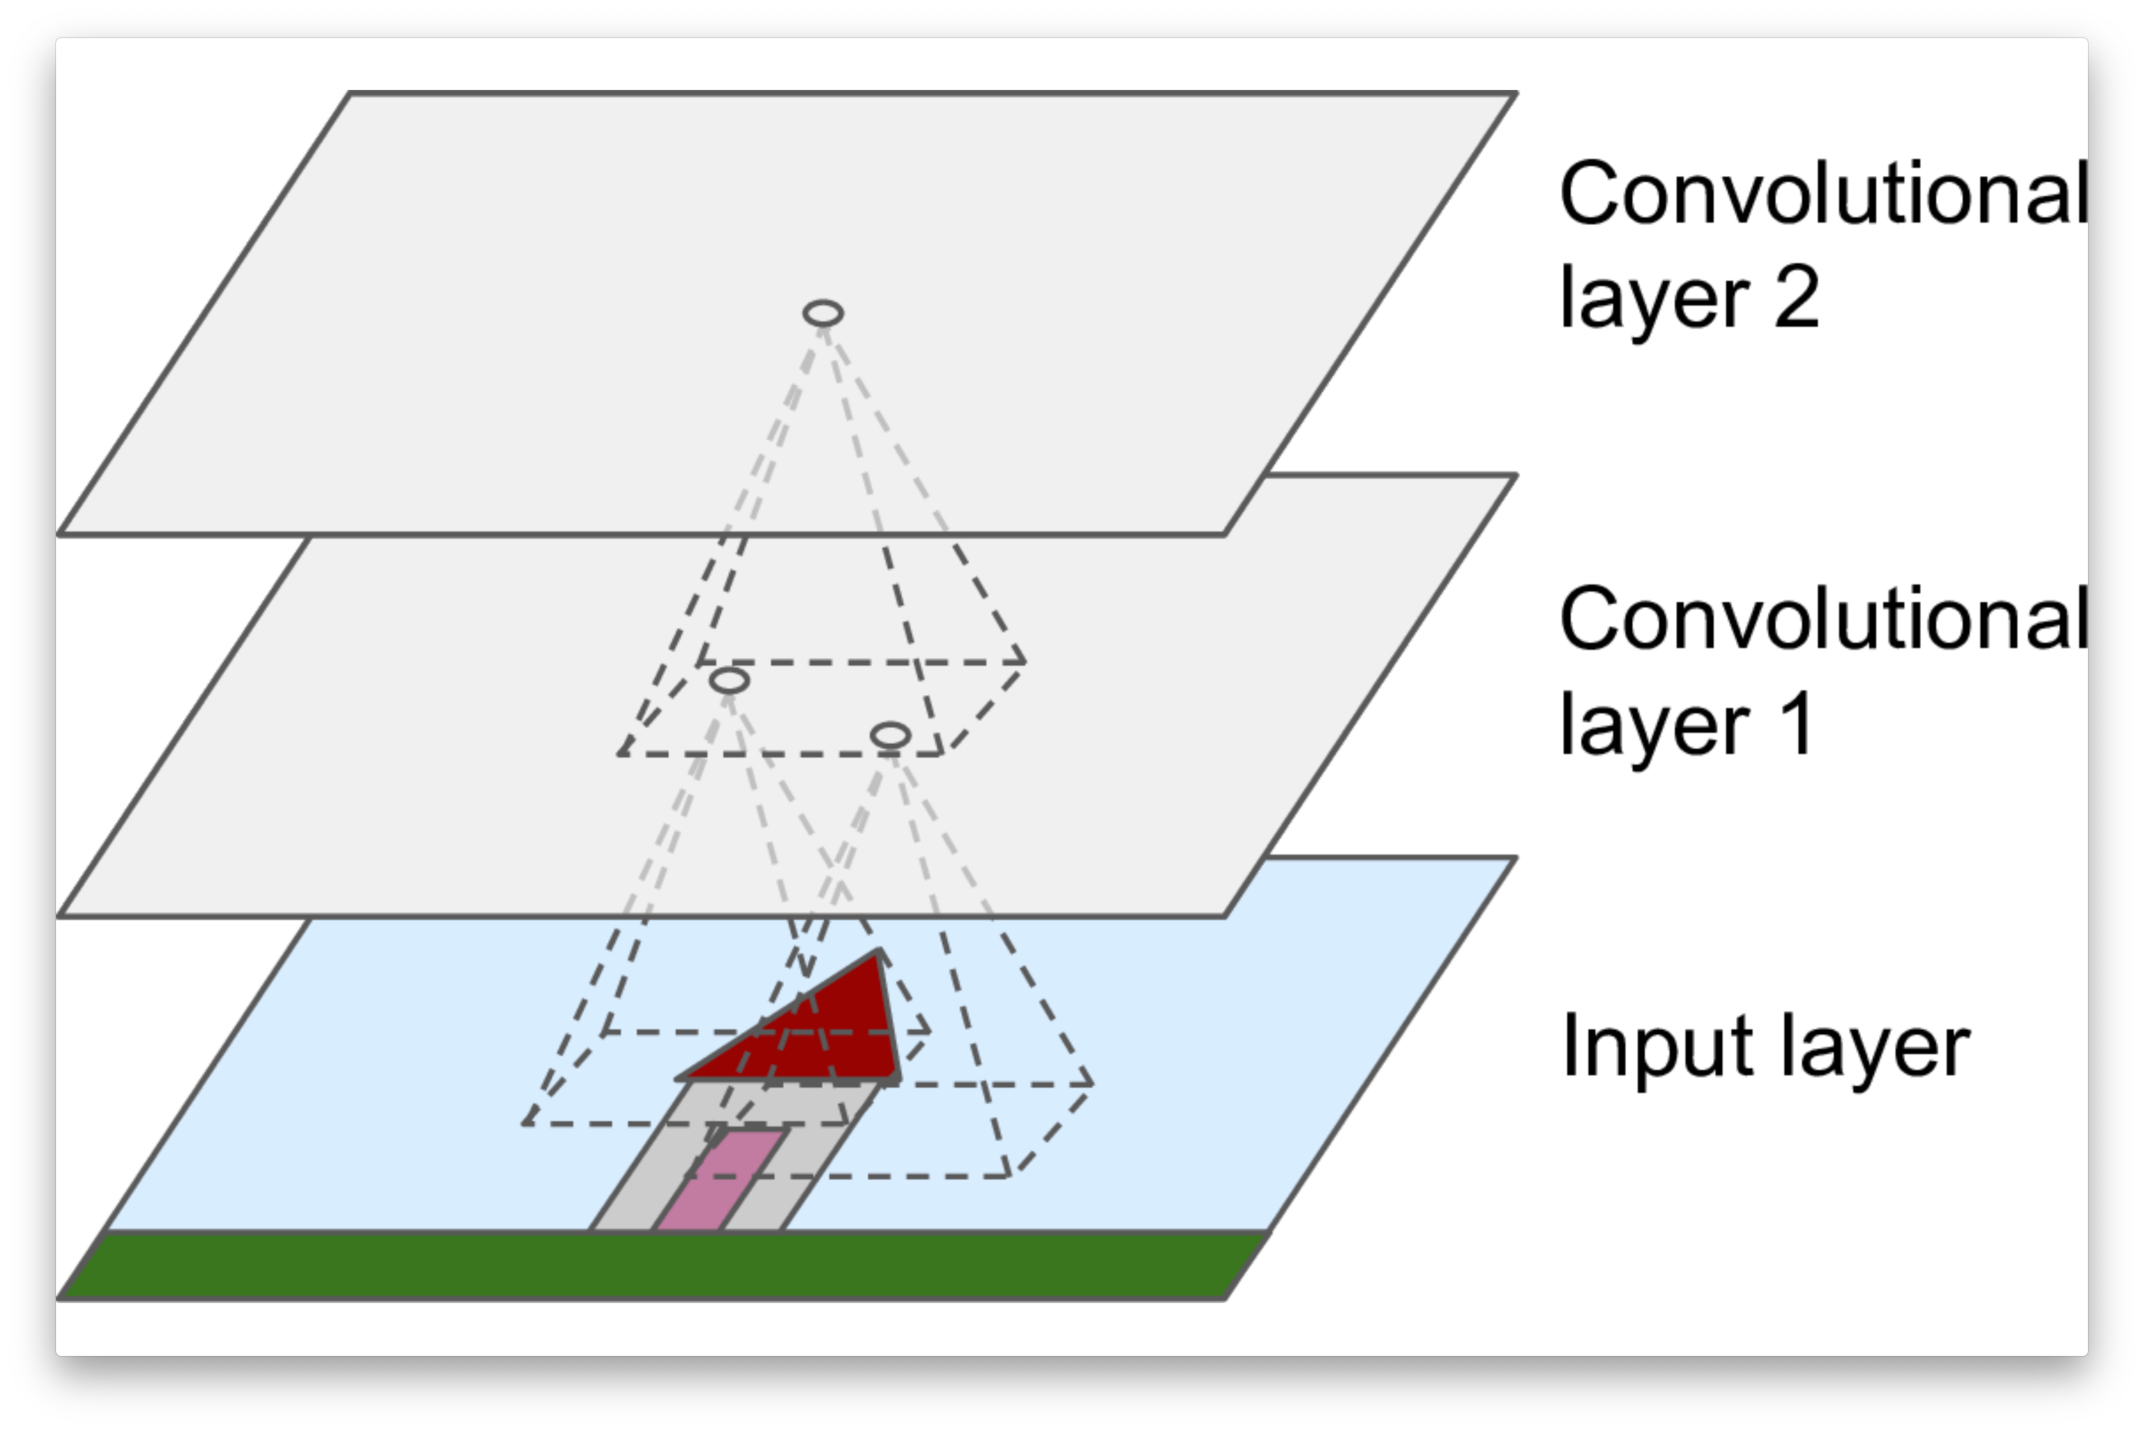

**Attribution**: Géron (2019) Figure 14.2

## Champ récepteur

- Chaque unité est connectée aux neurones de ses **champs récepteurs**.
  - L’unité $i,j$ dans la couche $l$ est connectée aux unités de $i$ à
    $i+f_h-1$, $j$ à $j+f_w-1$ de la couche $l-1$, où $f_h$ et $f_w$
    sont respectivement la **hauteur** et la **largeur** du **champ
    récepteur**.

## Padding

**Zero padding**. Pour conserver des couches de même taille, la grille
peut être remplie de zéros.

## Padding

Pas de padding

[![](https://github.com/vdumoulin/conv_arithmetic/raw/master/gif/no_padding_no_strides.gif)](https://github.com/vdumoulin/conv_arithmetic/blob/master/gif/no_padding_no_strides.gif)

Padding moitié

[![](https://github.com/vdumoulin/conv_arithmetic/raw/master/gif/same_padding_no_strides.gif)](https://github.com/vdumoulin/conv_arithmetic/blob/master/gif/same_padding_no_strides.gif)

Padding complet

[![](https://github.com/vdumoulin/conv_arithmetic/raw/master/gif/full_padding_no_strides.gif)](https://github.com/vdumoulin/conv_arithmetic/blob/master/gif/full_padding_no_strides.gif)

**Attribution**:
[github.com/vdumoulin/conv_arithmetic](https://github.com/vdumoulin/conv_arithmetic/)

## Stride

**Stride**. Il est possible de connecter une couche $(l-1)$ plus grande
à une couche $(l)$ plus petite en sautant des unités. Le nombre d’unités
sautées est appelé **stride**, $s_h$ et $s_w$.

. . .

- L’unité $i,j$ dans la couche $l$ est connectée aux unités de
  $i \times s_h$ à $i \times s_h + f_h - 1$, $j \times s_w$ à
  $j \times s_w + f_w - 1$ de la couche $l-1$, où $f_h$ et $f_w$ sont
  respectivement la **hauteur** et la **largeur** du **champ
  récepteur**, $s_h$ et $s_w$ sont respectivement la **hauteur** et la
  **largeur** du **stride**.

## Stride

Pas de padding, stride

[![](https://github.com/vdumoulin/conv_arithmetic/raw/master/gif/no_padding_strides.gif)](https://github.com/vdumoulin/conv_arithmetic/blob/master/gif/no_padding_strides.gif)

Padding, stride

[![](https://github.com/vdumoulin/conv_arithmetic/raw/master/gif/padding_strides.gif)](https://github.com/vdumoulin/conv_arithmetic/blob/master/gif/padding_strides.gif)

**Attribution**:
[github.com/vdumoulin/conv_arithmetic](https://github.com/vdumoulin/conv_arithmetic/)

# Filtres

## Filtres

- Une **fenêtre** de taille $f_h \times f_w$ est déplacée sur la sortie
  des couches $l-1$, appelée **carte de attributs d’entrée**, position
  par position.

- **Pour chaque emplacement**, le produit est calculé entre la partie
  extraite et une matrice de la même taille, appelée **noyau
  convolutionnel** ou **filtre**. La **somme** des valeurs dans la
  matrice résultante constitue la **sortie** pour cet emplacement.

# Modèle

## Modèle

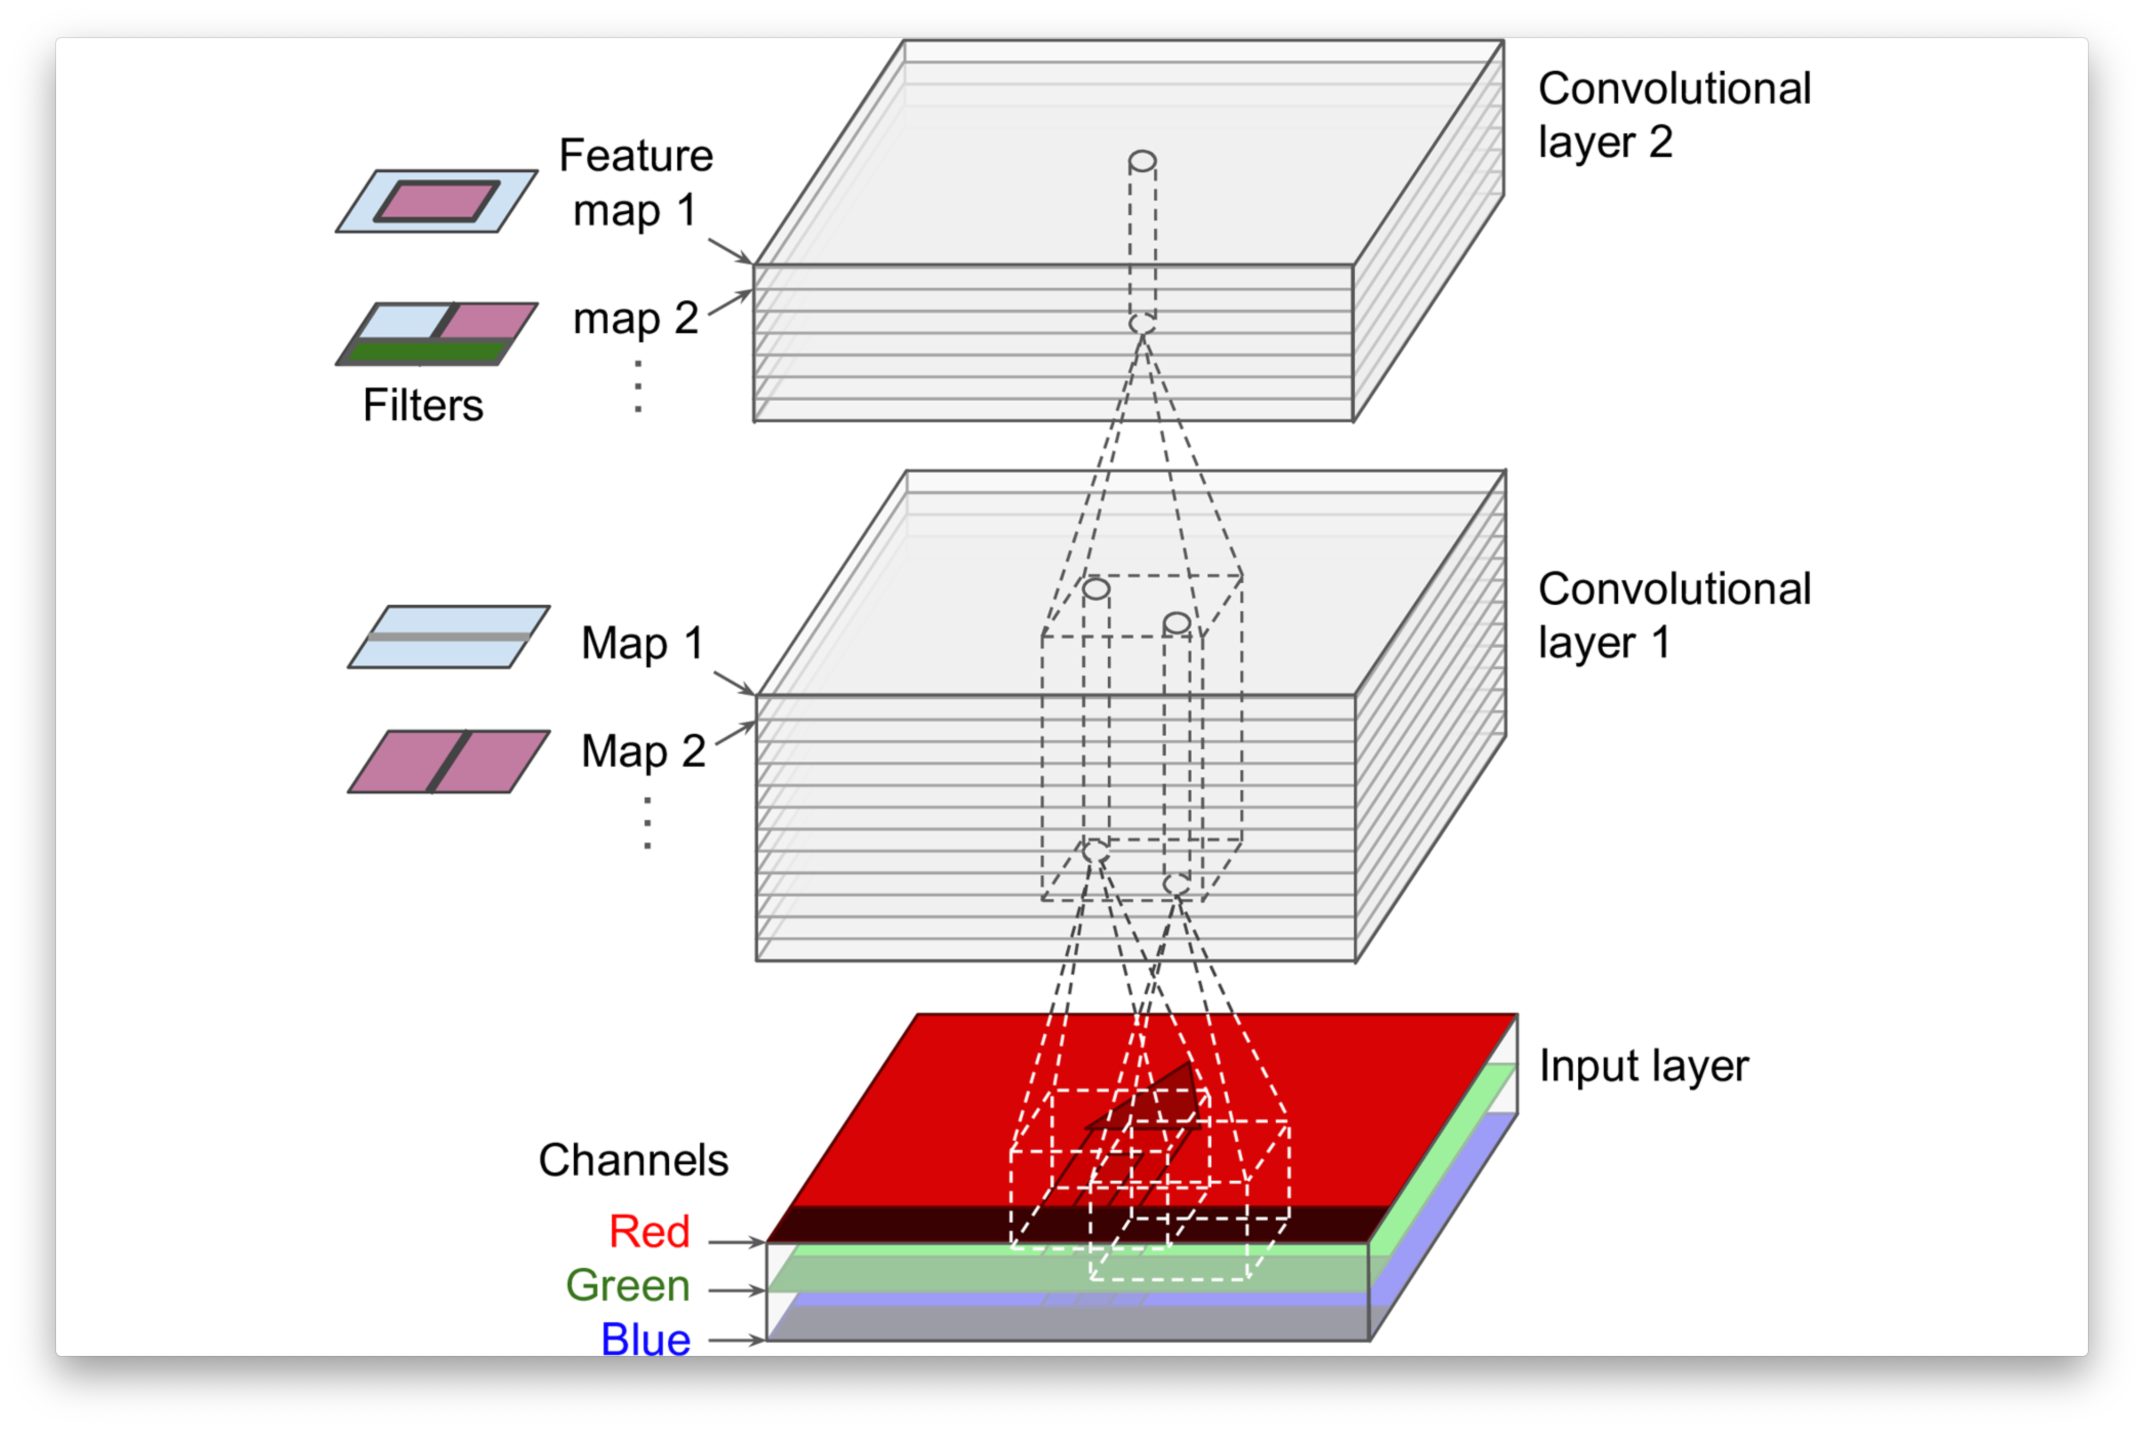

$$
z_{i,j,k} = b_k + \sum_{u=0}^{f_h-1} \sum_{v=0}^{f_w-1} \sum_{k'=0}^{f_{n'}-1} x_{i',j',k'} \cdot w_{u,v,k',k}
$$

où $i' = i \times s_h + u$ et $j' = j \times s_w + v$.

**Attribution:** Géron (2019) Figure 14.6

## Couche convolutionnelle

- “Ainsi, une couche remplie de neurones utilisant le **même filtre**
  produit une **carte de d’attributs**.”

- “Bien sûr, il n’est pas nécessaire de définir les filtres manuellement
  : au lieu de cela, **pendant l’entraînement, la couche
  convolutionnelle apprendra automatiquement les filtres les plus utiles
  pour sa tâche**.”

Géron (2019) § 14

## Couche convolutionnelle

- “(…) et **les couches supérieures apprendront à les combiner en des
  motifs plus complexes**.”

- “Le fait que **tous les neurones d’une carte d’attributs** **partagent
  les mêmes paramètres** réduit considérablement le nombre de paramètres
  du modèle.”

Géron (2019) § 14

## Résumé

1.  **Carte d’attributs (*feature map*) :** Dans les réseaux neuronaux
    convolutifs (CNNs), la sortie d’une opération de convolution est
    appelée une carte d’attributs. Elle capture les attributs de
    l’entrée sous une forme simplifiée et localisée par rapport au
    filtre appliqué.

## Résumé

1.  **Paramètres du noyau :** Les paramètres du noyau sont appris via le
    processus de rétropropagation, permettant au réseau d’optimiser ses
    capacités d’extraction d’attributs en fonction des données
    d’entraînement.

## Résumé

1.  **Terme de biais :** Un seul terme de biais est ajouté uniformément
    à toutes les entrées de la carte d’attributs. Ce biais aide à
    ajuster le niveau d’activation, offrant une flexibilité
    supplémentaire au réseau pour mieux ajuster les données.

## Résumé

1.  **Fonction d’activation :** Après l’ajout du biais, les valeurs de
    la carte d’attributs passent généralement par une fonction
    d’activation, telle que ReLU (Rectified Linear Unit). La fonction
    ReLU introduit une non-linéarité en mettant à zéro les valeurs
    négatives tout en conservant les valeurs positives, permettant ainsi
    au réseau d’apprendre des motifs plus complexes.

# Pooling

## Pooling

- Une **couche de pooling** présente des similitudes avec une **couche
  convolutionnelle**.

  - Chaque neurone dans une couche de pooling est connecté à un ensemble
    de neurones au sein d’un **champ récepteur**.

- Cependant, contrairement aux couches convolutionnelles, les couches de
  pooling ne possèdent pas de **poids**.

  - Elles produisent plutôt une sortie en appliquant une fonction
    d’agrégation, généralement **maximale** ou **moyenne**.

Comme pour les couches convolutionnelles, les couches de pooling
permettent de spécifier la taille du champ récepteur, le padding et le
stride. Pour la fonction `MaxPool2D`, la taille par défaut du champ
récepteur est $2 \times 2$.

Dans une couche de pooling, en particulier le max pooling, la fonction
max est intrinsèquement non différentiable car elle implique de
sélectionner la valeur maximale parmi un ensemble d’entrées. Cependant,
dans le contexte de la rétropropagation dans les réseaux de neurones,
nous pouvons contourner ce problème en utilisant un concept connu sous
le nom de “gradient de la fonction max”.

Voici comment cela fonctionne :

1.  **Passage avant** : Lors du passage avant, la couche de max pooling
    sélectionne la valeur maximale de chaque région de pooling (par
    exemple, une fenêtre 2x2) et transmet ces valeurs à la couche
    suivante.

2.  **Rétropropagation** : Lors de la rétropropagation, le gradient est
    propagé uniquement à l’entrée qui correspondait à la valeur maximale
    lors du passage avant. Cela signifie que la dérivée est 1 pour la
    position qui détenait la valeur maximale et 0 pour toutes les autres
    positions dans la fenêtre de pooling.

Cette approche permet effectivement à l’opération max de participer aux
processus d’optimisation basés sur le gradient, comme la
rétropropagation, même si la fonction max elle-même est non
différentiable. En assignant le gradient à la position de la valeur
maximale, le réseau peut apprendre quelles caractéristiques sont les
plus importantes pour la tâche à accomplir.

## Pooling

- Ce processus de sous-échantillonnage conduit à une **réduction de la
  taille du réseau** ; chaque fenêtre de dimensions $f_h \times f_w$ est
  condensée en une seule valeur, généralement le **maximum** ou la
  **moyenne** de cette fenêtre.

- Selon Géron (2019), une couche de pooling max offre un certain degré
  d’**invariance aux petites translations** (§ 14).

## Pooling

1.  **Réduction dimensionnelle :** Les couches de pooling réduisent les
    dimensions spatiales (largeur et hauteur) des cartes d’attributs
    d’entrée. Cette réduction diminue le nombre de paramètres et la
    charge computationnelle dans le réseau, ce qui peut aider à prévenir
    le sur-apprentissage.

## Pooling

1.  **Extraction des attributs :** En résumant la présence d’attributs
    dans une région, les couches de pooling permettent de conserver les
    informations les plus critiques tout en éliminant les détails moins
    importants. Ce processus permet au réseau de se concentrer sur les
    attributs les plus saillantes.

## Pooling

1.  **Invariance à la translation :** Le pooling introduit un degré
    d’invariance aux translations et distorsions dans l’entrée. Par
    exemple, le max pooling capture la caractéristique la plus marquante
    dans une région locale, rendant le réseau moins sensible aux petits
    décalages ou variations dans l’entrée.

## Pooling

1.  **Réduction du bruit :** Le pooling peut aider à lisser le bruit
    dans l’entrée en agrégeant l’information sur une région, mettant
    ainsi en évidence les attributs cohérents par rapport aux variations
    aléatoires.

## Pooling

1.  **Apprentissage hiérarchique des attributs :** En réduisant
    progressivement les dimensions spatiales à travers les couches, les
    couches de pooling permettent au réseau de construire une
    représentation hiérarchique des données d’entrée, capturant des
    attributs de plus en plus abstraites et complexes à des couches plus
    profondes.

## Keras

In [20]:
import tensorflow as tf
from functools import partial  

DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, padding="same", activation="relu", kernel_initializer="he_normal") 

model = tf.keras.Sequential([     
  DefaultConv2D(filters=64, kernel_size=7, input_shape=[28, 28, 1]), 
  tf.keras.layers.MaxPool2D(),     
  DefaultConv2D(filters=128),
  DefaultConv2D(filters=128),
  tf.keras.layers.MaxPool2D(),
  DefaultConv2D(filters=256),
  DefaultConv2D(filters=256),
  tf.keras.layers.MaxPool2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(units=128, activation="relu", kernel_initializer="he_normal"),     
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(units=64, activation="relu", kernel_initializer="he_normal"),
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(units=10, activation="softmax") ])  

model.summary()

/Users/turcotte/.virtualenvs/csi4106/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type) ┃ Output Shape ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 ( Conv2D ) │ ( None , 28 , 28 , 64 ) │ 3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 ( MaxPooling2D ) │ ( None , 14 , 14 , 64 ) │ 0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 ( Conv2D ) │ ( None , 14 , 14 , 128 ) │ 73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 ( Conv2D ) │ ( None , 14 , 14 , 128 ) │ 147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 ( MaxPooling2D ) │ ( None , 7 , 7 , 128 ) │ 0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 ( Conv2D ) │ ( None , 7 , 7 , 256 ) │ 295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 ( Conv2D ) │ ( None , 7 , 7 , 256 ) │ 590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 ( MaxPooling2D ) │ ( None , 3 , 3 , 256 ) │ 0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 ( Flatten ) │ ( None , 2304 ) │ 0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 ( Dense ) │ ( None , 128 ) │ 295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 ( Dropout ) │ ( None , 128 ) │ 0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 ( Dense ) │ ( None , 64 ) │ 8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 ( Dropout ) │ ( None , 64 ) │ 0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 ( Dense ) │ ( None , 10 ) │ 650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

Total params: 1,413,834 (5.39 MB)

Trainable params: 1,413,834 (5.39 MB)

Non-trainable params: 0 (0.00 B)

Géron (2022) Chapitre 11, précision de test de 92% sur le jeu de données
Fashion-MNIST

Le modèle précédemment discuté, qui comprenait des couches entièrement
connectées (Dense), atteignait une précision de test de 88%.

Nous allons maintenant examiner le pooling.

## Réseaux neuronaux convolutifs

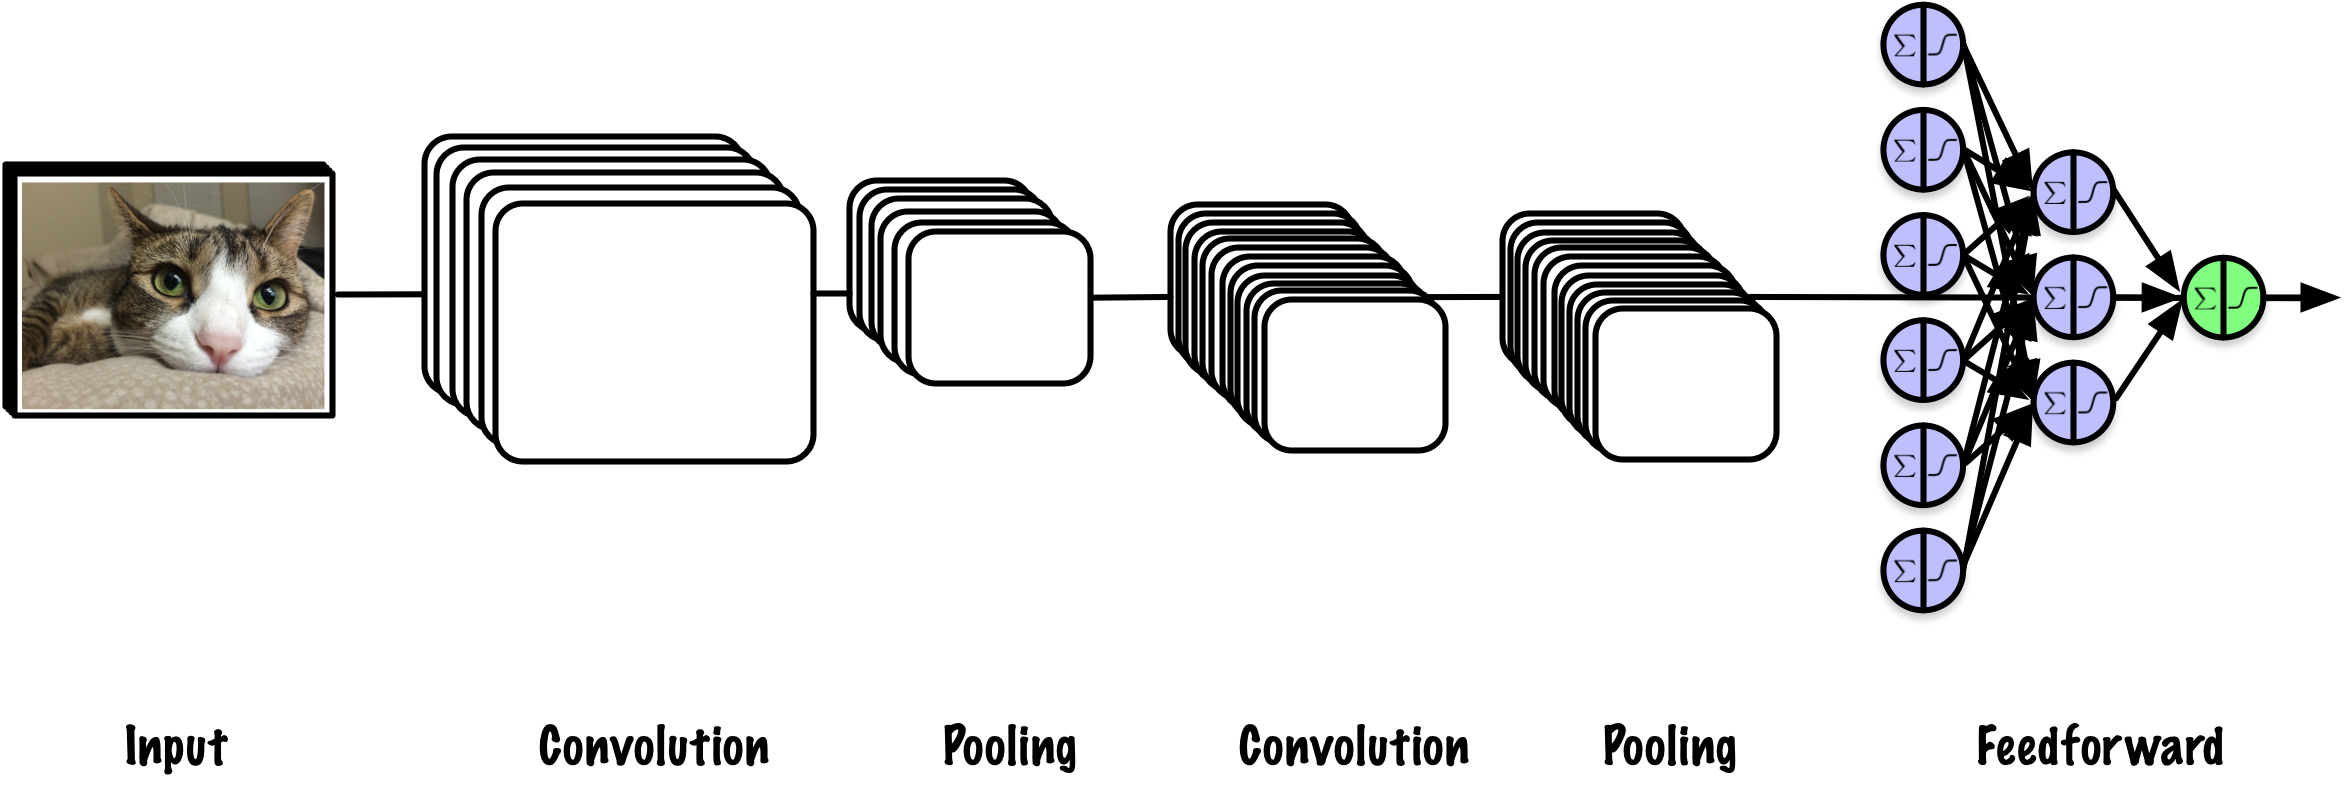

L’architecture consiste à empiler séquentiellement plusieurs couches
convolutionnelles, chacune suivie d’une couche d’activation ReLU, puis
d’une couche de pooling. Au fur et à mesure que ce processus se
poursuit, les dimensions spatiales de la représentation de l’image
diminuent. En parallèle, le nombre de cartes de caractéristiques
augmente, comme illustré dans notre exemple Keras. Au sommet de cette
pile, un réseau de neurones entièrement connecté est intégré.

## AlexNet



Krizhevsky et al. (2012)

**Attribution**: Prince (2023)

AlexNet se compose de huit couches avec des paramètres apprenables :
cinq couches de convolution suivies de trois couches entièrement
connectées. L’architecture comprend également des couches de
max-pooling, des fonctions d’activation ReLU et un dropout pour
améliorer les performances d’entraînement et réduire le
surapprentissage.

## VGG



Simonyan et Zisserman (2015)

**Attribution**: Prince (2023)

Des informations complémentaires se trouvent sur [ce
site](https://www.robots.ox.ac.uk/~vgg/research/very_deep/).

> Convolutional networks (ConvNets) currently set the state of the art
> in visual recognition. The aim of this project is to investigate how
> the ConvNet depth affects their accuracy in the large-scale image
> recognition setting.

> Our main contribution is a rigorous evaluation of networks of
> increasing depth, which shows that a significant improvement on the
> prior-art configurations can be achieved by increasing the depth to
> 16-19 weight layers, which is substantially deeper than what has been
> used in the prior art. To reduce the number of parameters in such very
> deep networks, we use very small 3×3 filters in all convolutional
> layers (the convolution stride is set to 1). Please see our
> publication for more details.

## Performance des ConvNets



**Attribution**: Prince (2023)

## StatQuest

<https://youtu.be/HGwBXDKFk9I>

La vidéo présente un exemple simple différenciant les images de la
lettre O et de la lettre X, en utilisant un seul filtre. Cela simplifie
l’explication et la rend facile à suivre. En pratique, cependant, chaque
couche convolutionnelle contient généralement des dizaines voire des
centaines de filtres.

## Dernier mot

Comme vous pouvez l’imaginer, le **nombre de couches** et de **filtres**
sont des hyperparamètres qui sont optimisés par le biais de
**l’ajustement des hyperparamètres**.

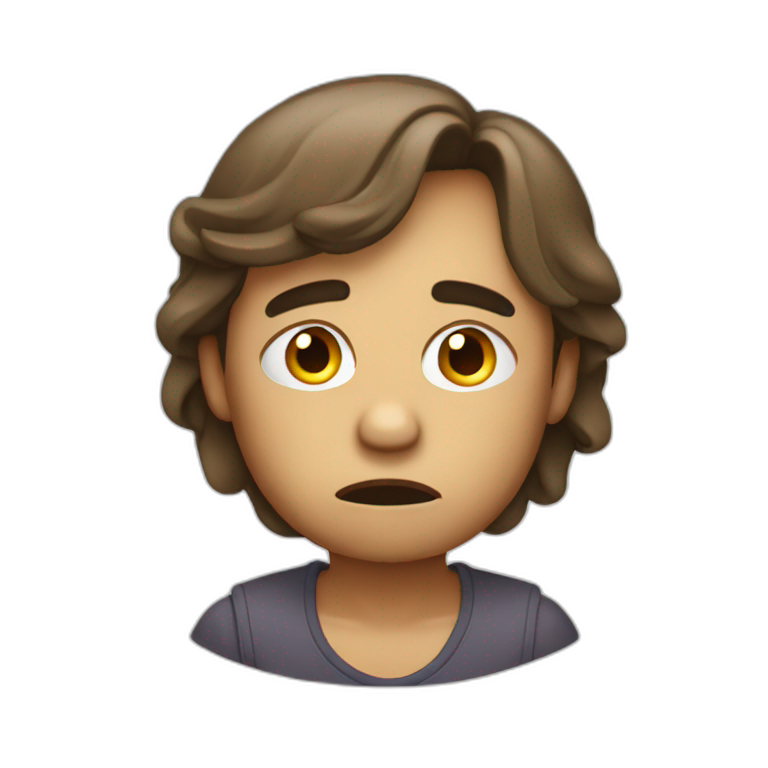

**Attribution**:
[@stefaan_cotteni](https://emojis.sh/emoji/desperate-and-discouraged-emoji-xiBgGFCW51)

# Prologue

## Résumé

- Hiérarchie des concepts en apprentissage profond
- Noyaux et opérations de convolution
- Champ récepteur, remplissage (padding) et pas (stride)
- Filtres et cartes des attributs
- Couches convolutionnelles
- Couches de pooling

**Résumé**

- **Hiérarchie des concepts en apprentissage profond**
  - Les modèles d’apprentissage profond représentent les données à
    travers des couches d’abstraction croissante.
  - Chaque couche apprend des motifs basés sur les sorties des couches
    précédentes (“motifs de motifs”).
  - Cet apprentissage hiérarchique réduit la dépendance à l’ingénierie
    manuelle des attributs.
  - Les réseaux profonds atteignent de meilleures performances avec
    moins de paramètres par rapport aux réseaux peu profonds.
- **Réseaux de neurones convolutionnels (CNN)**
  - Les CNN se spécialisent dans le traitement des données avec une
    topologie en grille (par ex., images).
  - Ils détectent des motifs locaux en utilisant des couches de
    convolution avec des poids partagés.
  - Les neurones dans les couches de convolution se connectent
    uniquement dans leurs champs récepteurs, et ne sont pas entièrement
    connectés.
  - Cette connectivité locale et le partage des poids réduisent
    considérablement le nombre de paramètres.
- **Noyaux et opérations de convolution**
  - Les noyaux (filtres) sont de petites matrices qui glissent sur les
    données d’entrée pour effectuer des convolutions.
  - L’opération de convolution implique une multiplication élément par
    élément et une sommation.
  - Les noyaux peuvent être conçus pour détecter des attributs
    spécifiques comme les contours et les textures.
  - Des cartes de attributs sont générées, mettant en évidence où
    certaines attributs sont détectées dans l’entrée.
- **Champ récepteur, remplissage (padding) et pas (stride)**
  - **Champ récepteur** : La région locale de l’entrée à laquelle un
    neurone est sensible.
  - **Remplissage (padding)** : Ajout de zéros autour de l’entrée pour
    maintenir les dimensions spatiales après convolution.
  - **Pas (stride)** : La taille de l’étape avec laquelle le noyau se
    déplace sur les données d’entrée.
  - Ces paramètres contrôlent la taille de sortie et le calcul dans les
    couches de convolution.
- **Filtres et cartes d’attributs**
  - Les filtres sont appris pendant l’entraînement et sont essentiels
    pour la détection des attributs.
  - Tous les neurones dans une carte d’attributs partagent les mêmes
    paramètres de filtre.
  - Ce partage conduit à une utilisation efficace des paramètres et à
    une détection cohérente des attributs dans l’entrée.
- **Couches convolutionnelles**
  - Effectuent des convolutions suivies de l’ajout d’un terme de biais
    et de l’application d’une fonction d’activation (par ex., ReLU).
  - La fonction d’activation introduit une non-linéarité, permettant au
    réseau d’apprendre des motifs complexes.
  - L’utilisation de poids et de biais partagés réduit le nombre total
    de paramètres.
- **Couches de pooling**
  - **But** : Réduire les dimensions spatiales des cartes de attributs
    pour contrôler le surapprentissage et le calcul.
  - **Types** :
    - **Max pooling** : Prend la valeur maximale dans une fenêtre de
      pooling.
    - **Average pooling** : Calcule la valeur moyenne dans une fenêtre
      de pooling.
  - **Avantages** :
    - La réduction dimensionnelle conduit à moins de paramètres et à un
      calcul plus rapide.
    - Introduit une invariance à la translation, rendant le réseau
      robuste aux décalages et distorsions.
- **Construction d’architectures CNN**
  - Les CNN sont construits en empilant des couches de convolution et de
    pooling.
  - Les dimensions spatiales diminuent tandis que le nombre de cartes
    d’attributs augmente dans les couches plus profondes.
  - Se termine souvent par des couches entièrement connectées pour les
    tâches de classification.
  - Des architectures d’exemple peuvent être implémentées en utilisant
    des frameworks comme Keras.
- **Réglage des hyperparamètres**
  - Les hyperparamètres clés incluent le nombre de couches, de filtres,
    de tailles de noyaux, de pas et de remplissage.
  - Un réglage approprié est essentiel pour atteindre des performances
    optimales du modèle.
  - Le surapprentissage peut être contrôlé en utilisant des techniques
    comme le dropout et la régularisation.
- **Directions futures**
  - **Attribution de attributs** :
    - Essentielles pour les applications nécessitant une explicabilité
      (par ex., voitures autonomes).
  - **Apprentissage par transfert** :
    - Implique l’utilisation de modèles pré-entraînés pour de nouvelles
      tâches afin d’économiser du temps et des ressources.
    - Particulièrement utile lorsque les données annotées sont rares.

## Directions futures

Lors de l’intégration des CNN dans vos projets, envisagez d’explorer les
sujets suivants :

- **Attribution de attributs** : Diverses techniques sont disponibles
  pour visualiser ce que le réseau a appris. Par exemple, dans le
  contexte des voitures autonomes, il est crucial de s’assurer que le
  réseau se concentre sur des attributs pertinents, évitant les
  distractions.

- **Apprentissage par transfert** : Cette approche permet la
  réutilisation des poids de réseaux pré-entraînés, ce qui accélère le
  processus d’apprentissage, réduit les besoins en calcul et facilite
  l’entraînement du réseau même avec un nombre limité d’exemples.

Il existe aussi des convultion 1D. Elles trouvent souvent leurs
applications en bio-informatique.

## Lectures Complémentaires

![](https://mit-press-new-us.imgix.net/covers/9780262048644.jpg?auto=format&w=298&dpr=2&q=80)

- [Understanding Deep Learning](http://udlbook.com) (Prince 2023) est un
  manuel récemment publié qui se concentre sur les concepts fondamentaux
  de l’apprentissage profond.

- Il commence par les principes de base et s’étend à des sujets
  contemporains tels que les transformateurs, les modèles de diffusion,
  les réseaux de neurones graphiques, les autoencodeurs, les réseaux
  adversariaux et l’apprentissage par renforcement.

- Le manuel vise à aider les lecteurs à comprendre ces concepts sans
  entrer excessivement dans les détails théoriques.

- Il comprend soixante-huit exercices sous forme de cahiers Python.

- Le livre suit un modèle “lire d’abord, payer plus tard”.

## Ressources

- **Un guide de l’arithmétique de convolution pour l’apprentissage
  profond**
- Auteurs : Vincent Dumoulin et Francesco Visin
- Dernière révision : 11 janvier 2018
  - [arXiv:1603.07285](https://arxiv.org/abs/1603.07285)
  - [Dépôt GitHub](https://github.com/vdumoulin/conv_arithmetic/)

## Prochain cours

- Nous introduirons les espaces de solutions.

## Références

Géron, Aurélien. 2019. *Hands-on Machine Learning with Scikit-Learn,
Keras, and TensorFlow*. 2nd éd. O’Reilly Media.

Géron, Aurélien. 2022. *Hands-on Machine Learning with Scikit-Learn,
Keras, and TensorFlow*. 3ᵉ éd. O’Reilly Media, Inc.

Goodfellow, Ian, Yoshua Bengio, et Aaron Courville. 2016. *Deep
Learning*. Adaptive computation et machine learning. MIT Press.
<https://dblp.org/rec/books/daglib/0040158>.

Krizhevsky, Alex, Ilya Sutskever, et Geoffrey E Hinton. 2012. « ImageNet
Classification with Deep Convolutional Neural Networks ». In *Advances
in Neural Information Processing Systems*, édité par F. Pereira, C. J.
Burges, L. Bottou, et K. Q. Weinberger, vol. 25. Curran Associates, Inc.
<https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf>.

LeCun, Yann, Yoshua Bengio, et Geoffrey Hinton. 2015. « Deep learning ».
*Nature* 521 (7553): 436‑44. <https://doi.org/10.1038/nature14539>.

Lecun, Y., L. Bottou, Y. Bengio, et P. Haffner. 1998. « Gradient-based
learning applied to document recognition ». *Proceedings of the IEEE* 86
(11): 2278‑324. <https://doi.org/10.1109/5.726791>.

Prince, Simon J. D. 2023. *Understanding Deep Learning*. The MIT Press.
<http://udlbook.com>.

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

Simonyan, Karen, et Andrew Zisserman. 2015. « Very Deep Convolutional
Networks for Large-Scale Image Recognition ». *International Conference
on Learning Representations*.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de **science informatique** et de génie électrique (**SI**GE)

Université d’Ottawa